# Example 5: Wood-Berry Column Control

This example models the behaviour of a distillation column described in ["Terminal composition control of a binary distillation column"](https://www.sciencedirect.com/science/article/pii/0009250973800259). The Wood-Berry column is a canonical benchmark for linear MIMO (Multiple Input, Multiple Output) systems in process control literature.

## Imports

The required packages are: `Akson` for the core functionality, `torch` for defining state-space system matrices, and `matplotlib` for plotting.

In [1]:
import akson
import torch
import mini_ode
import sympy as sp
import matplotlib.pyplot as plt

## Plant Transfer Function

The transfer function matrix for the Wood-Berry distillation column is defined below. This transfer function represents a linearised local model of the distillation column at its operating point. The model is valid only within a neighbourhood of the operating point.

In [2]:
s = sp.symbols('s')
H = sp.Matrix([
        [128/(167*s + 10), -189/(210*s + 10)],
        [66/(109*s + 10), -194/(144*s + 10)]
    ])
H

Matrix([
[128/(167*s + 10), -189/(210*s + 10)],
[ 66/(109*s + 10), -194/(144*s + 10)]])

## Defining the System Dynamics

State-space dynamics are constructed from the transfer function matrices using the `from_tf` static method. An operating point input and output is specified, defining the linearisation point from which the local model is derived. The model validity range is also specified to constrain simulations within the region where the linear approximation holds.

In [3]:
system_dynamics = akson.StateSpaceDynamics.from_tf(
    H, s, 
    operating_point_u=torch.tensor([1.95, 1.71], dtype=torch.float64),
    operating_point_y=torch.tensor([96.0, 0.5], dtype=torch.float64),
    u_min=torch.tensor([0.0, 0.0], dtype=torch.float64),
    u_max=torch.tensor([2.2, 2.0], dtype=torch.float64),
    y_min=torch.tensor([90.0, 0.0], dtype=torch.float64),
    y_max=torch.tensor([100.0, 5.0], dtype=torch.float64)
)
system_dynamics

/home/antoni/Documents/PRACA/akson/src/akson/state_space_system.py:1168: RuntimeWarning: Large coefficients detected in A[(1, 2)], consider normalizing the transfer function.
  warnings.warn(
/home/antoni/Documents/PRACA/akson/src/akson/state_space_system.py:1168: RuntimeWarning: Large coefficients detected in B[(1, 1)], consider normalizing the transfer function.
  warnings.warn(
/home/antoni/Documents/PRACA/akson/src/akson/state_space_system.py:1168: RuntimeWarning: Large coefficients detected in C[(0, 2)], consider normalizing the transfer function.
  warnings.warn(


The plant's operating point:

In [4]:
print(system_dynamics.operating_point)

OperatingPoint(u=[1.95, 1.71], x=[0.0, 0.0, 0.0, 0.0], y=[96.0, 0.5])


## Retrieve step responses for DMC regulator

The discrete step response is computed over a duration of $125$ time units with time step $5$:

In [5]:
dt = 5.0
duration = 125.0
t_step, y_step = system_dynamics.discrete_step_response(duration=duration, dt=dt)

The timepoints tensor has the shape `[number of steps]`. The step response tensor has the shape `[number of steps, number of outputs, number of inputs]`. The actual shapes are printed below:

In [6]:
print(t_step.shape, y_step.shape)

torch.Size([26]) torch.Size([26, 2, 2])


The discrete step response is plotted below (`extended_t` is required for `stairs` to work properly):

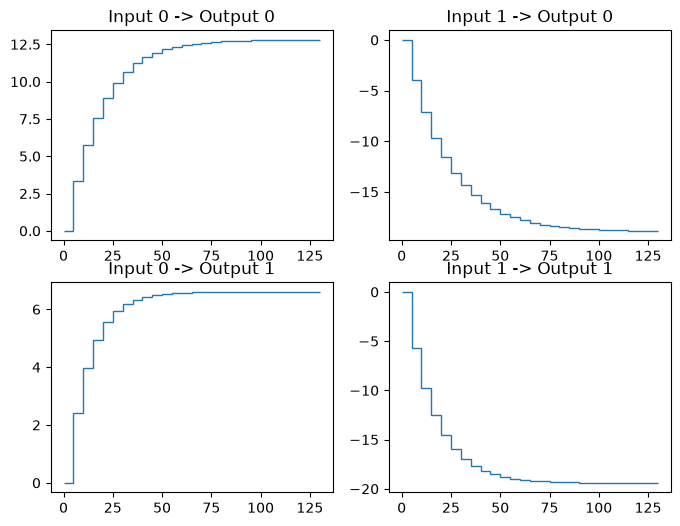

In [7]:
extended_t = torch.cat((t_step, 2*t_step[-1:len(t_step)]-t_step[-2:-1]), dim=0)
plt.figure(figsize=(8, 6))
plt.subplot(221)
plt.stairs(y_step[:, 0, 0], extended_t, baseline=None)
plt.title('Input 0 -> Output 0')
plt.subplot(222)
plt.stairs(y_step[:, 0, 1], extended_t, baseline=None)
plt.title('Input 1 -> Output 0')
plt.subplot(223)
plt.stairs(y_step[:, 1, 0], extended_t, baseline=None)
plt.title('Input 0 -> Output 1')
plt.subplot(224)
plt.stairs(y_step[:, 1, 1], extended_t, baseline=None)
plt.title('Input 1 -> Output 1')
plt.show()

## DMC regulator

The DMC regulator is configured with the following parameters: prediction horizon $N = 30$, control horizon $N_u = 26$, regularisation factor $2.0$, and input/output constraints as defined by the operating range. Change-in-input constraints are applied to limit actuator movement.

In [8]:
N = 30
Nu = 26
dmc_config = akson.DMCRegulatorConfiguration(
    y_step, N, Nu, system_dynamics.operating_point,
    u_min=torch.tensor([0.0, 0.0], dtype=torch.float64),
    u_max=torch.tensor([2.2, 2.0], dtype=torch.float64),
    du_min=torch.tensor([-0.1, -0.1], dtype=torch.float64),
    du_max=torch.tensor([0.1, 0.1], dtype=torch.float64),
    regularisation=2.
)
dmc_state = akson.DMCRegulatorState.initial_state_for(dmc_config)
dmc_closed_loop = akson.DMCRegulatorClosedSystem(system_dynamics, dmc_config, dmc_state)

A piecewise-constant reference trajectory is defined:

In [9]:
r_traj = torch.tensor(
    [[96., 0.5]]*5 +
    [[96., 3.5]]*5 +
    [[99., 2.5]]*31
)

The simulation is run over a duration of time $200$ units:

In [10]:
t, y, u = dmc_closed_loop.simulate(
    r_traj=r_traj,
    duration=200.,
    dt=dt,
    num_substeps=5
)

The system output is plotted alongside the reference trajectory below:

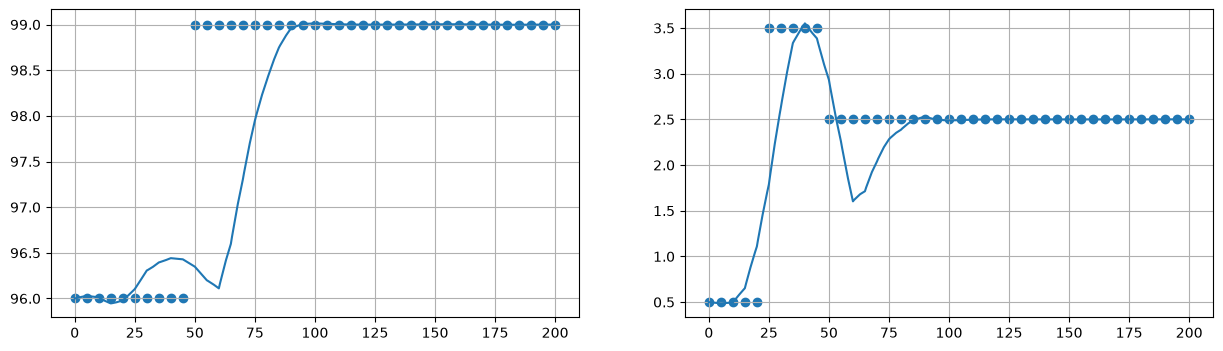

In [11]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.plot(t, y[:,0])
plt.scatter(torch.arange(r_traj.shape[0])*dt, r_traj[:,0])
plt.grid()
plt.subplot(122)
plt.plot(t, y[:,1])
plt.scatter(torch.arange(r_traj.shape[0])*dt, r_traj[:,1])
plt.grid()
plt.show()

The control signal generated by the DMC regulator is plotted below:

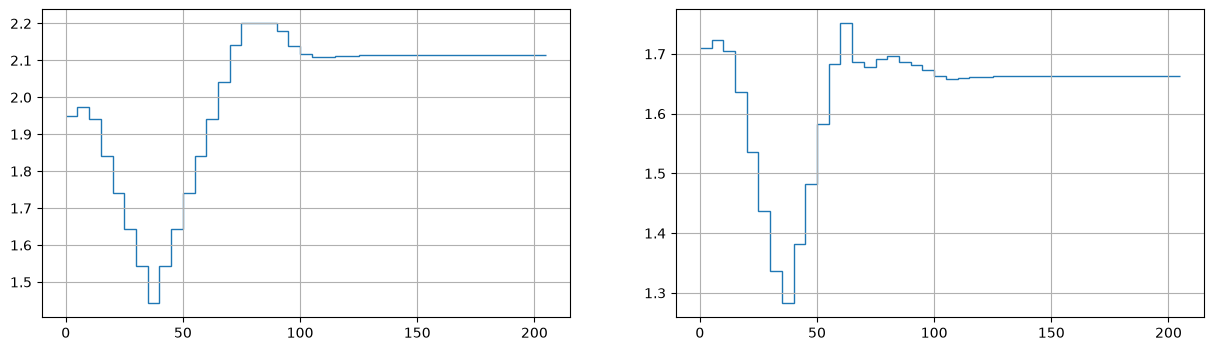

In [12]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.stairs(u[:,0], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.subplot(122)
plt.stairs(u[:,1], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.show()

## DMC with polishing

The DMC regulator is reconfigured with the polishing option enabled. This means that refinement of the calculated control is performed by the `Active-Set` polishing algorithm to improve tracking accuracy beyond the standard DMC solution.

In [13]:
N = 30
Nu = 26
dmc_config = akson.DMCRegulatorConfiguration(
    y_step, N, Nu, system_dynamics.operating_point,
    u_min=torch.tensor([0.0, 0.0], dtype=torch.float64),
    u_max=torch.tensor([2.2, 2.0], dtype=torch.float64),
    du_min=torch.tensor([-0.1, -0.1], dtype=torch.float64),
    du_max=torch.tensor([0.1, 0.1], dtype=torch.float64),
    regularisation=2.,
    use_polishing=True
)
dmc_state = akson.DMCRegulatorState.initial_state_for(dmc_config)
dmc_closed_loop = akson.DMCRegulatorClosedSystem(system_dynamics, dmc_config, dmc_state)

The simulation is run over a duration of $200$ time units:

In [14]:
t, y, u = dmc_closed_loop.simulate(
    r_traj=r_traj,
    duration=200.,
    dt=dt,
    num_substeps=5
)

The system output is plotted alongside the reference trajectory below:

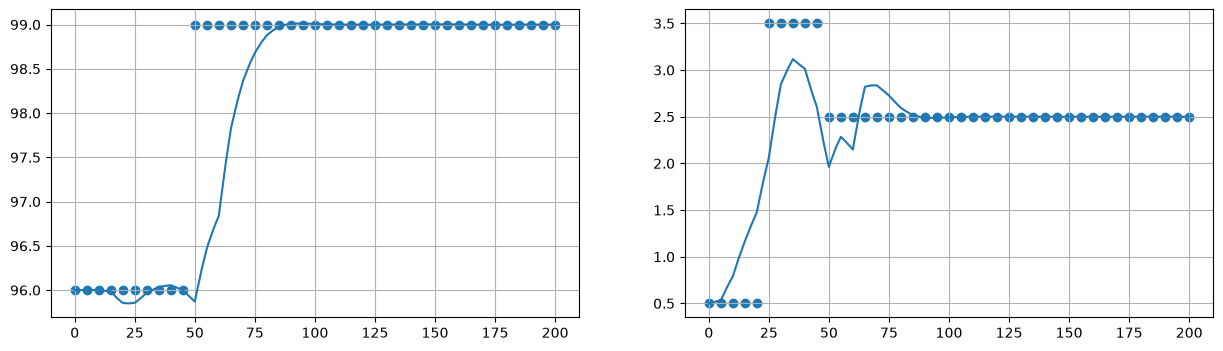

In [15]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.plot(t, y[:,0])
plt.scatter(torch.arange(r_traj.shape[0])*dt, r_traj[:,0])
plt.grid()
plt.subplot(122)
plt.plot(t, y[:,1])
plt.scatter(torch.arange(r_traj.shape[0])*dt, r_traj[:,1])
plt.grid()
plt.show()

The control signal generated by the DMC regulator is plotted below:

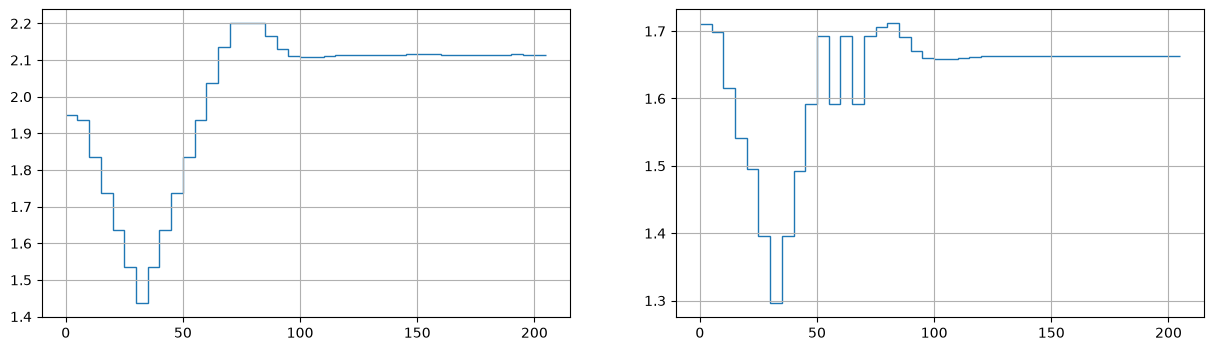

In [16]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.stairs(u[:,0], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.subplot(122)
plt.stairs(u[:,1], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.show()

## QDMC regulator

The Quadratic DMC (QDMC) regulator is configured, with explicit output constraints incorporated into the optimisation problem. This ensures that output trajectories remain within the prescribed bounds throughout the simulation.

In [17]:
N = 30
Nu = 26
dmc_config = akson.QDMCRegulatorConfiguration(
    y_step, N, Nu, system_dynamics.operating_point,
    u_min=torch.tensor([0.0, 0.0], dtype=torch.float64),
    u_max=torch.tensor([2.2, 2.0], dtype=torch.float64),
    du_min=torch.tensor([-0.1, -0.1], dtype=torch.float64),
    du_max=torch.tensor([0.1, 0.1], dtype=torch.float64),
    y_min=torch.tensor([90.0, 0.0], dtype=torch.float64),
    y_max=torch.tensor([100.0, 5.0], dtype=torch.float64)
)
dmc_state = akson.QDMCRegulatorState.initial_state_for(dmc_config)
dmc_closed_loop = akson.QDMCRegulatorClosedSystem(system_dynamics, dmc_config, dmc_state)

The simulation is run over a duration of $200$ time units:

In [18]:
t, y, u = dmc_closed_loop.simulate(
    r_traj=r_traj,
    duration=200.,
    dt=dt,
    num_substeps=5
)

/home/antoni/Documents/PRACA/akson/src/akson/_dmc_common.py:270: RuntimeWarning: RKF45: integration completed with 9 rejected and 3 accepted steps; consider relaxing tolerances or using an implicit solver for stiff problems
  t_sub, x_sub = solver.solve(traced_ode_fn, t_span, y0)


The system output is plotted alongside the reference trajectory below:

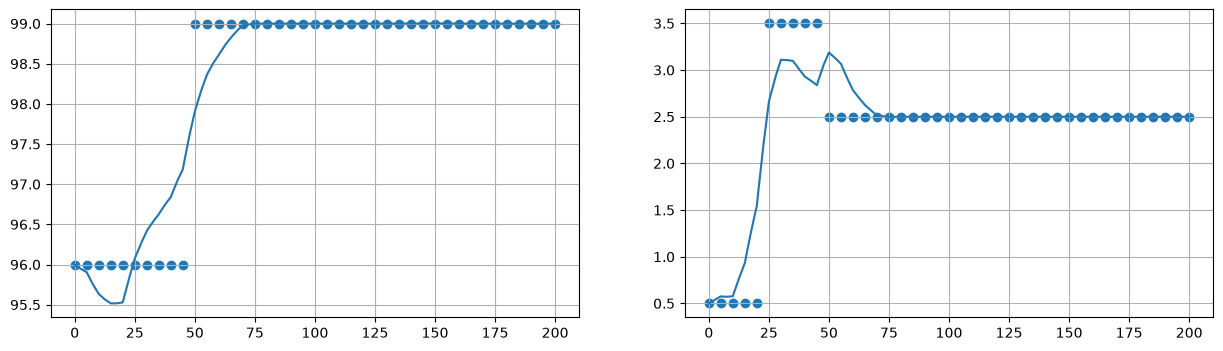

In [19]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.plot(t, y[:,0])
plt.scatter(torch.arange(r_traj.shape[0])*dt, r_traj[:,0])
plt.grid()
plt.subplot(122)
plt.plot(t, y[:,1])
plt.scatter(torch.arange(r_traj.shape[0])*dt, r_traj[:,1])
plt.grid()
plt.show()

The control signal generated by the QDMC regulator is plotted below:

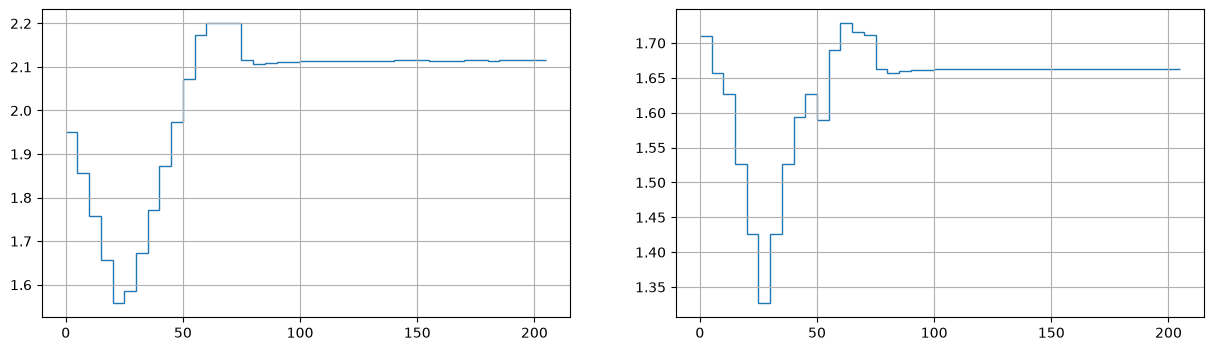

In [20]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.stairs(u[:,0], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.subplot(122)
plt.stairs(u[:,1], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.show()

### PID regulator

A conventional PID regulator is configured with two decoupled channels. The derivative term ($T_d$) is set to a negligible value ($10^{-10}$) to effectively disable it for both channels. The time step is reduced to $dt = 0.25$ for better PID regulator behaviour.

In [21]:
dt = 0.25
pid_config = akson.PIDRegulatorConfiguration(
    n_inputs=2, n_outputs=2, channels=[
        akson.PIDChannel(input_idx=0, output_idx=0, K=1., Ti=5., Td=1e-10),
        akson.PIDChannel(input_idx=1, output_idx=1, K=-1., Ti=5., Td=1e-10)
    ],
    u0=torch.tensor([1.95, 1.711]),
    u_min=torch.tensor([0.0, 0.0], dtype=torch.float64),
    u_max=torch.tensor([2.2, 2.0], dtype=torch.float64),
    t=dt
)
pid_state = akson.PIDRegulatorState(n_inputs=2, n_outputs=2)
pid_closed_system = akson.PIDRegulatorClosedSystem(
    system_dynamics, torch.tensor([0.0, 0.0, 0.0, 0.0], dtype=torch.float64),
    pid_config, pid_state
)

Setpoints for PID regulator are defined:

In [22]:
setpoints = torch.tensor(
    [[96., 0.5]]*100 +
    [[96., 3.5]]*100 +
    [[99., 2.5]]*600
)

The simulation is run over a duration of $200$ time units:

In [23]:
t, y, u = pid_closed_system.simulate(
    setpoints=setpoints,
    duration=200,
    num_substeps=5
)

The system output is plotted alongside the reference trajectory below:

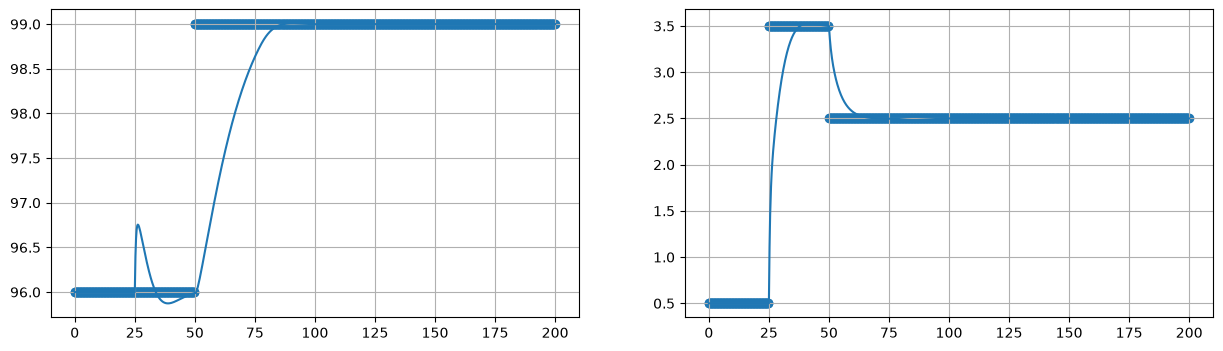

In [24]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.plot(t, y[:,0])
plt.scatter(torch.arange(0., setpoints[:,0].shape[0]*dt, dt), setpoints[:,0])
plt.grid()
plt.subplot(122)
plt.plot(t, y[:,1])
plt.scatter(torch.arange(0., setpoints[:,1].shape[0]*dt, dt), setpoints[:,1])
plt.grid()
plt.show()

The control signal generated by the PID regulator is plotted below:

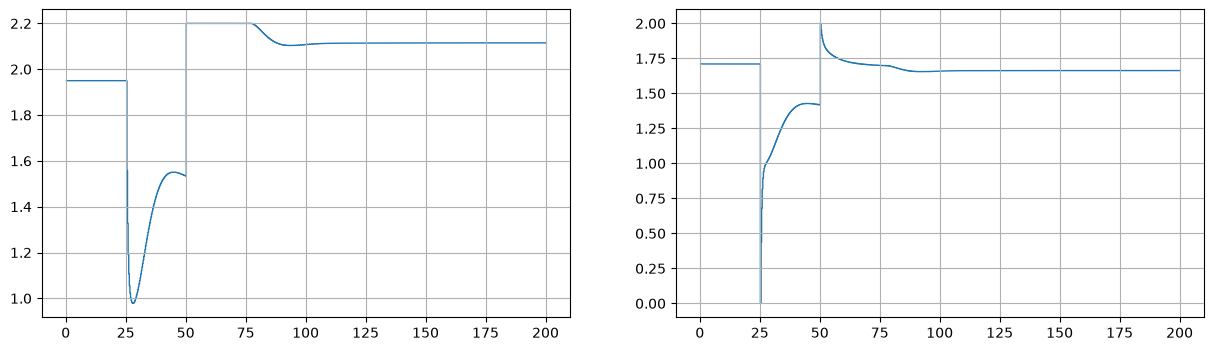

In [25]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plt.stairs(u[:,0], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.subplot(122)
plt.stairs(u[:,1], torch.arange(0., 200.+2*dt, dt), baseline=None)
plt.grid()
plt.show()